# What is Robot Framework?

**Robot Framework** is an open-source test automation framework for ACCEPTANCE TESTING.
* It follows a different test case style:
    * Keyword Driven Testing
    * Behavior Driven Testing
    * Data Driven Testing
* Robot Framework has an easy syntax, utilizing human-readable keywords. 
* Provides standard automation & testing capabilities and framework features with minimal coding. 
* Libraries provide actual automation and testing capabilities to Robot Framework by providing keywords.
* Its capabilities can be extended by libraries implemented with Python or Java.
* Robot Framework is extensively used for WEB, API, RPA & DB testing.

**Robot Framework gives inbuilt support for**:
* Excellent HTML Reports.
* Complete logging of the Test Execution.
* Tagging and executing the selected tests.
* Parameterizing the Tests with multiple data sets.
* Data Driven Testing Capabilities.
* Setup and Tear Down methods at the Test Case or Test Suite level.
* Parallel execution of Tests with thread-safety.
* Framework tests can be integrated with the CI/CD Jenkins.

# Robot Framework Setup & Configurationn

* Install Python
* Set up Python Environment Variables
* Install Robot Framework: `pip3 install robotframework`
* Install Selenium Library: `pip3 install robotframework-seleniumlibrary`
* Install PyCharm
* Create a new Project in PyCharm
* Add Robot Extension to PyCharm, such as **"Hyper RobotFramework Support"**

# `test_demo.robot`

> **NOTES**:
> * Robot Framework seleniumLibrary supports only ID, XPATH & CSS locators only.
> * Using **Input Password** keyword will not log the entered value in logs.
   
```
*** Settings ***
Documentation    To validate the login form
Library    SeleniumLibrary                    # importing SeleniumLibrary
Test Teardown    Close Browser               # Test Teardown executes after the script execution for cleanup

*** Variables ***
# any variables declared here are GLOBAL Variables
# Scope of GLOBAL VARIABLE - can be accessible anywhere in the file.
${login_error_msg_locator}    css:.alert-danger

*** Test Cases ***
Validate un-successful login
    open the browser with the mortgage payment url
    Fill the login form
    Wait until it checks and displays the error message
    Verify the error message is correct

*** Keywords ***
open the browser with the mortgage payment url
    Create Webdriver    Chrome
    Go To    https://rahulshettyacademy.com/loginpagePractise/

Fill the login form
    # Supports only ID, XPATH & CSS locator only}
    Input Text            id:username    Kiranmoy
    Input Password        id:password    Paul
    Click Button          signInBtn                    # for ID locator, no need to mention the locator type

Wait until it checks and displays the error message
    Wait Until Element Is Visible    ${login_error_msg_locator}

Verify the error message is correct
    ${result}=    Get Text    ${login_error_msg_locator}       # here the result variable is a local variable and its scope is limited to this block only
    Should Be Equal As Strings    ${result}    Incorrect username/password.

    # compact & efficient step
    Element Text Should Be    ${login_error_msg_locator}    Incorrect username/password.
```

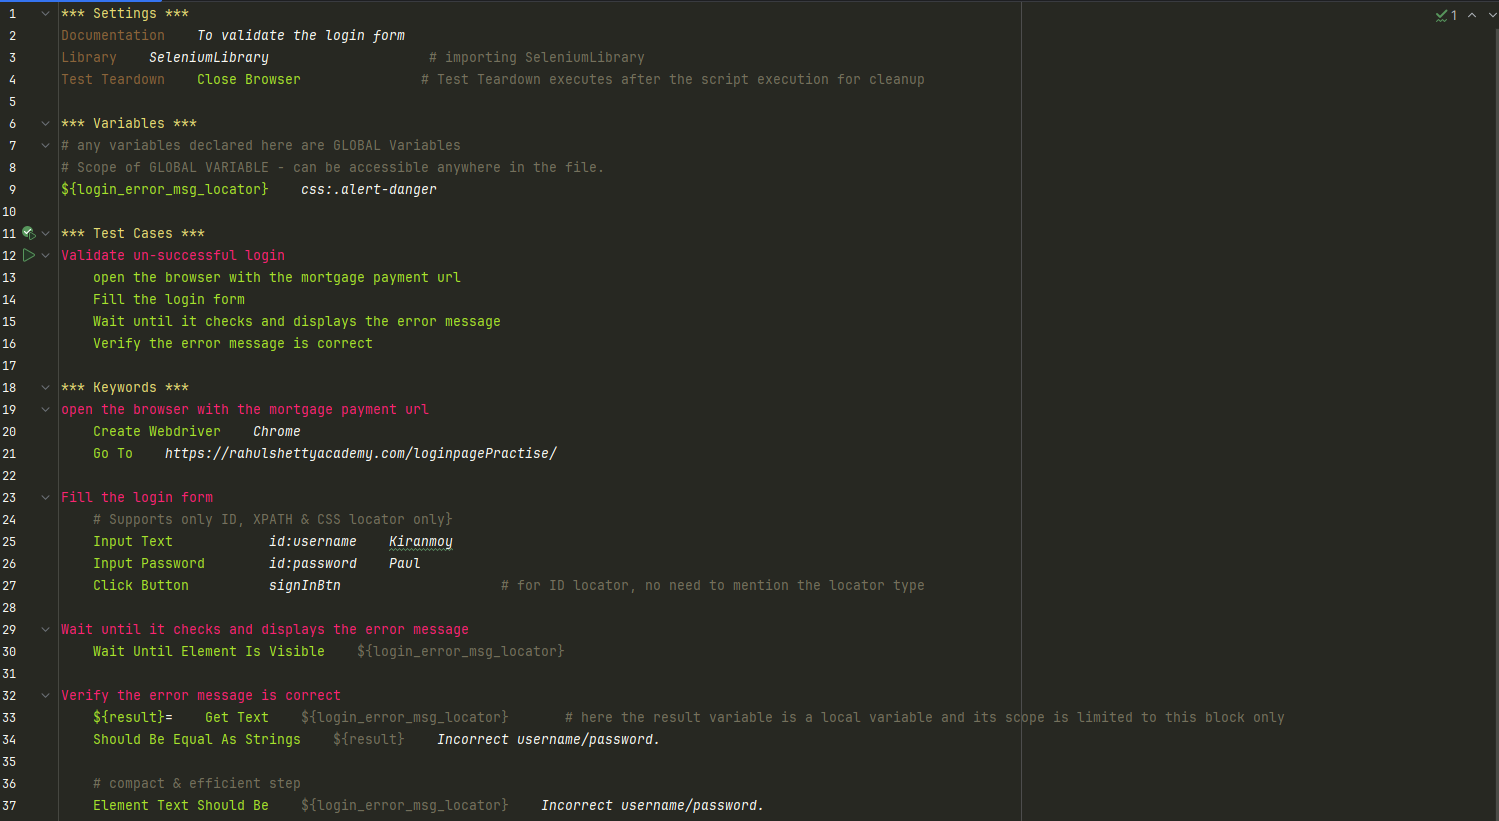


# Centralize re-usable code & keywords using `Resource File`

## `resource.robot`

```
*** Settings ***
# Multi line documentation using ... keyword
Documentation    A resource file with reusable keywords & variables
...              The system specific keywords created here from our own domain specific language.
...              They utilize keywords provided by the imported SeleniumLibrary.
Library          SeleniumLibrary

*** Variables ***
${user_name}            rahulshettyacademy
${invalid_password}     1234
${valid_password}       learning
${url}                  https://rahulshettyacademy.com/loginpagePractise/

*** Keywords ***
open the browser with the mortgage payment url
    Create Webdriver    Chrome
    Go To   ${url}
```

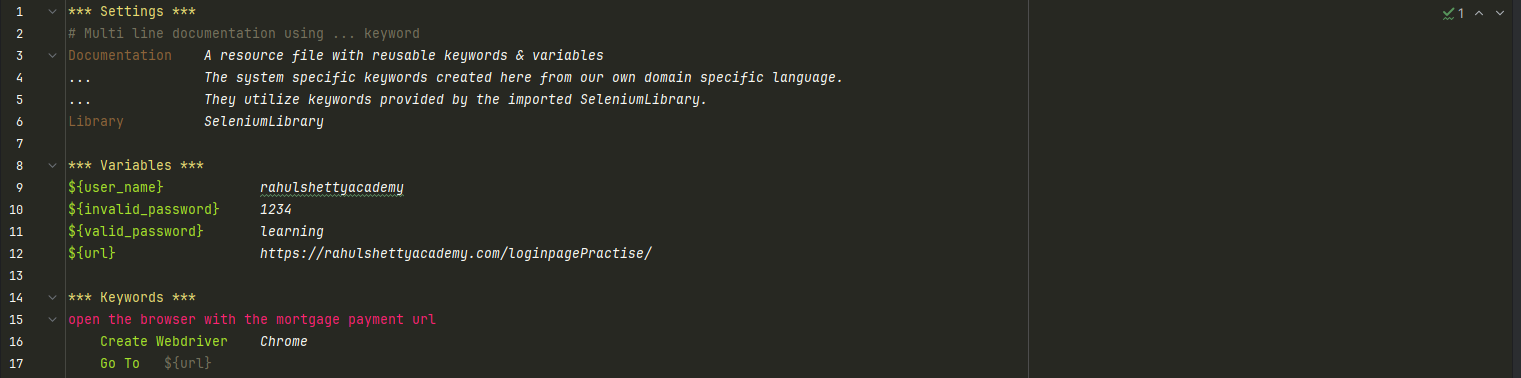

## `test_demo.robot`

```
*** Settings ***
Documentation        To validate the login form
Library              SeleniumLibrary                                    # importing SeleniumLibrary
Test Setup           open the browser with the mortgage payment url     # Test Setup executes before the script execution for test set up
Test Teardown        Close Browser                                      # Test Teardown executes after the script execution for cleanup
Resource             resource.robot

*** Variables ***
# any variables declared here are GLOBAL Variables
# Scope of GLOBAL VARIABLE - can be accessible anywhere in the file.
${login_error_msg_locator}    css:.alert-danger
${checkout_button_locator}      css:.nav-link

*** Test Cases ***

Validate un-successful login
    Fill the login form    ${user_name}    ${invalid_password}
    Wait Until Element Is Visible    ${login_error_msg_locator}
    Element Text Should Be    ${login_error_msg_locator}    Incorrect username/password.

Validate cards display in the shopping list
    Fill the login form    ${user_name}    ${valid_password}
    Wait Until Element Is Visible    ${checkout_button_locator}

*** Keywords ***
# Note that robot framework supports only ID, XPATH & CSS locator only.

# Parameterized test step/keyword
Fill the login form
    [arguments]           ${username}    ${password}
    Input Text            id:username    ${username}
    Input Password        id:password    ${password}
    Click Button          signInBtn                    # for ID locator, no need to mention the locator type

```

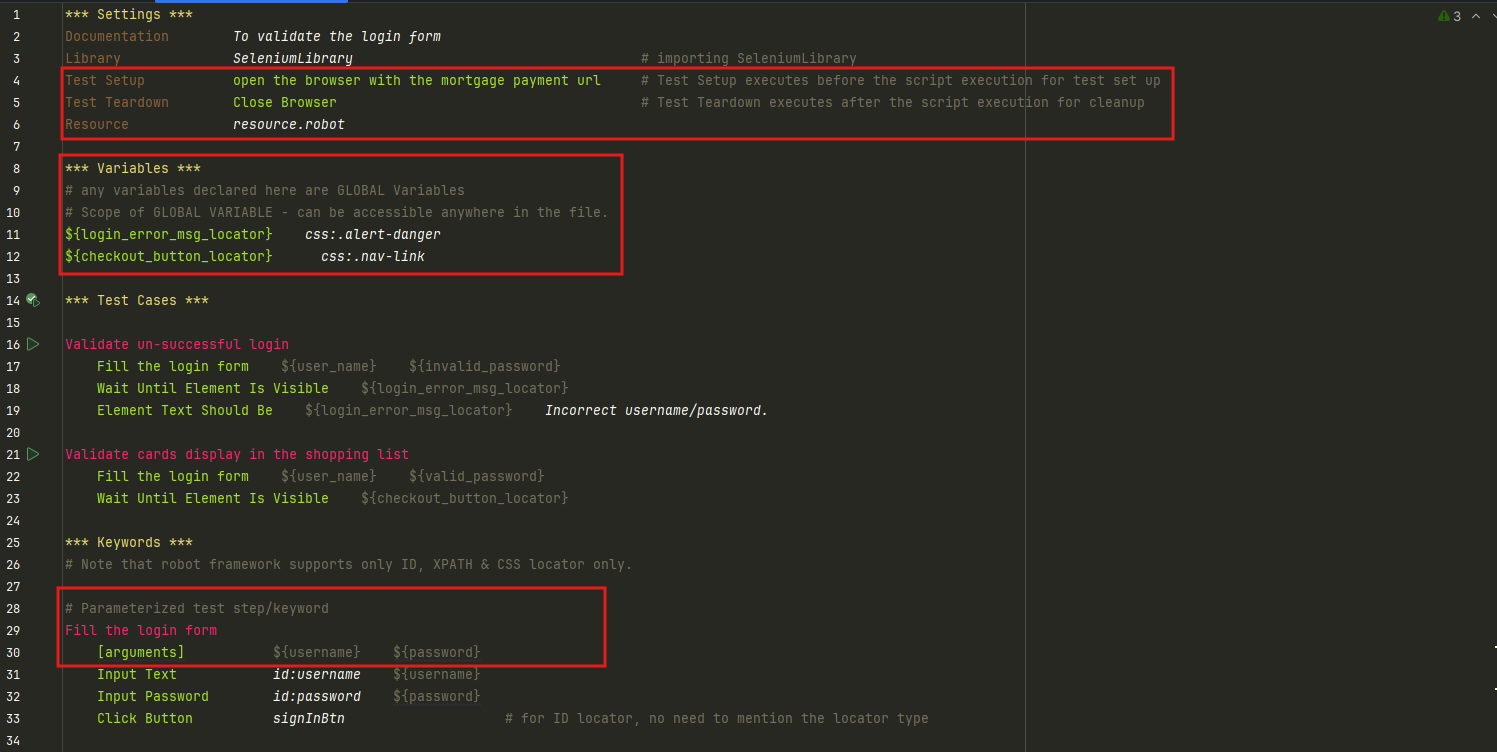